In [1]:
from pytential.sympy_pytential import sympy_pytential
from pytential.reduce import min_pytential
import numpy as np
from sympy import log, symbols
import matplotlib.pyplot as plt

This file demonstrates how to create, combine, and manipulate pytentials.  Equibilriation is used to reduce free variables. 

# Create phases

Create two binary ideal solutions

In [2]:
c0a, c1a, c0b, c1b, Va, Vb = symbols('c0a, c1a, c0b, c1b, Va, Vb')

In [3]:
RT = 8.134*300
fa_sp = c0a*RT*(1+log(c0a/(c0a+c1a))) +c1a*RT*(0+log(c1a/(c0a+c1a)))
fb_sp = c0b*RT*(0+log(c0b/(c0b+c1b))) +c1b*RT*(1+log(c1b/(c0b+c1b)))

In [4]:
fa = sympy_pytential(fa_sp, constraints_sym=[c0a+c1a-Va])
fb = sympy_pytential(fb_sp, constraints_sym=[c0b+c1b-Vb])
print('fa:', fa)

fa: x = ['Va', 'c0a', 'c1a']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c1a*log(c1a/(c0a + c1a))

f'(x)= [0, 2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c1a/(c0a + c1a))]

f"(x)= [[0, 0, 0], [0, 2440.2*c1a/(c0a*(c0a + c1a)), -2440.2/(c0a + c1a)], [0, -2440.2/(c0a + c1a), 2440.2*c0a/(c1a*(c0a + c1a))]]

Constraints:
0 = -Va + c0a + c1a



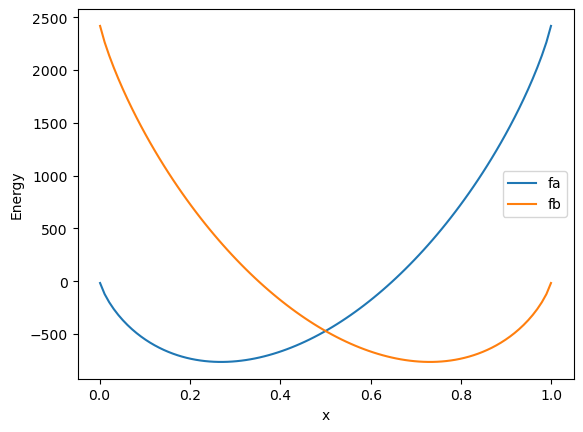

In [5]:
x_values = np.linspace(0.001, .999, 100)
ya = fa(c0a=x_values, c1a=1-x_values, Va = 1)
yb = fb(c0b=x_values, c1b=1-x_values, Vb = 1)

plt.plot(x_values, ya, label='fa')
plt.plot(x_values, yb, label='fb')
plt.xlabel('x')
plt.ylabel('Energy')
plt.legend()
plt.show()

# Combine functions

Combine functions into a composite pytential

In [6]:
f = fa+fb
print(f)

x = ['Va', 'Vb', 'c0a', 'c0b', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1)

f'(x)= [0, 0, 2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c0b/(c0b + c1b)), 2440.2*log(c1a/(c0a + c1a)), 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 2440.2*c1a/(c0a*(c0a + c1a)), 0, -2440.2/(c0a + c1a), 0], [0, 0, 0, 2440.2*c1b/(c0b*(c0b + c1b)), 0, -2440.2/(c0b + c1b)], [0, 0, -2440.2/(c0a + c1a), 0, 2440.2*c0a/(c1a*(c0a + c1a)), 0], [0, 0, 0, -2440.2/(c0b + c1b), 0, 2440.2*c0b/(c1b*(c0b + c1b))]]

Constraints:
0 = -Va + c0a + c1a
-Vb + c0b + c1b



Add a constraint for the total x. Note the function is now an argument of x1, x2, and x

In [7]:
c0, c1 = symbols('c0, c1')
f_constrained = f.add_constraints_sym([c0a+c0b-c0, c1a+c1b-c1]) 
print(f_constrained)

x = ['Va', 'Vb', 'c0', 'c0a', 'c0b', 'c1', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1)

f'(x)= [0, 0, 0, 2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c0b/(c0b + c1b)), 0, 2440.2*log(c1a/(c0a + c1a)), 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 2440.2*c1a/(c0a*(c0a + c1a)), 0, 0, -2440.2/(c0a + c1a), 0], [0, 0, 0, 0, 2440.2*c1b/(c0b*(c0b + c1b)), 0, 0, -2440.2/(c0b + c1b)], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, -2440.2/(c0a + c1a), 0, 0, 2440.2*c0a/(c1a*(c0a + c1a)), 0], [0, 0, 0, 0, -2440.2/(c0b + c1b), 0, 0, 2440.2*c0b/(c1b*(c0b + c1b))]]

Constraints:
0 = -Va + c0a + c1a
-Vb + c0b + c1b
-c0 + c0a + c0b
-c1 + c1a + c1b



In [8]:
f_min = min_pytential(f_constrained, ['c0', 'c1'])
x_values2 = np.linspace(0.0001, .9999, 50)
ym = f_min(c0=x_values2, c1=1-x_values2)

/usr/lib/python3/dist-packages/scipy/optimize/_optimize.py:404: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


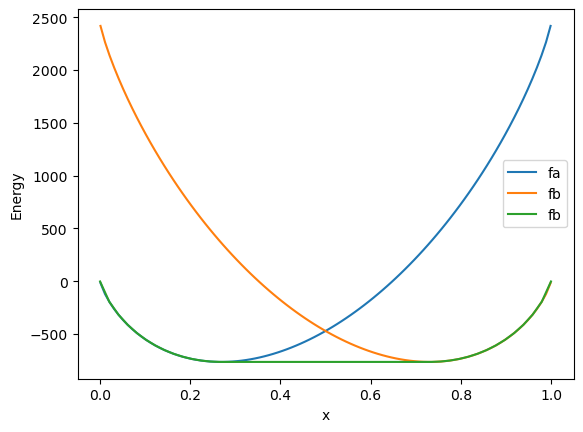

In [9]:
plt.plot(x_values, ya, label='fa')
plt.plot(x_values, yb, label='fb')
plt.plot(x_values2, ym, label='fb')
plt.xlabel('x')
plt.ylabel('Energy')
plt.legend()
plt.show()

In [17]:
f_constrained2 = f_constrained.add_constraints_sym([c0+c1-1, Va+Vb-1])
print(f_constrained2)

x = ['Va', 'Vb', 'c0', 'c0a', 'c0b', 'c1', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1)

f'(x)= [0, 0, 0, 2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c0b/(c0b + c1b)), 0, 2440.2*log(c1a/(c0a + c1a)), 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 2440.2*c1a/(c0a*(c0a + c1a)), 0, 0, -2440.2/(c0a + c1a), 0], [0, 0, 0, 0, 2440.2*c1b/(c0b*(c0b + c1b)), 0, 0, -2440.2/(c0b + c1b)], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, -2440.2/(c0a + c1a), 0, 0, 2440.2*c0a/(c1a*(c0a + c1a)), 0], [0, 0, 0, 0, -2440.2/(c0b + c1b), 0, 0, 2440.2*c0b/(c1b*(c0b + c1b))]]

Constraints:
0 = -Va + c0a + c1a
-Vb + c0b + c1b
-c0 + c0a + c0b
-c1 + c1a + c1b
c0 + c1 - 1
Va + Vb - 1



In [ ]:
f_min2 = min_pytential(f_constrained2, ['c0', 'Va'])

cont []
Pytential of type <class 'pytential.reduce.min_pytential.min_pytential'>
Variables: ['c0', 'Va']
Potential: <bound method args_to_list.<locals>.wrapper of <pytential.reduce.min_pytential.min_pytential object at 0x79f4ec4ef920>>
Gradient: <bound method args_to_list.<locals>.wrapper of <pytential.reduce.min_pytential.min_pytential object at 0x79f4ec4ef920>>
Hessian: <bound method args_to_list.<locals>.wrapper of <pytential.reduce.min_pytential.min_pytential object at 0x79f4ec4ef920>>



In [22]:
import numpy as np
import plotly.graph_objects as go

# Define the range of values for the two arguments
c0_values = np.linspace(0.0001, 0.9999, 10)  # Range for c0
Va_values = np.linspace(0.0001, 0.9999, 10)  # Range for Va

# Create a meshgrid for the two arguments
C0, Va = np.meshgrid(c0_values, Va_values)

# Evaluate f_min2 for each pair of (c0, Va)
F_min2 = np.zeros_like(C0)
for i in range(C0.shape[0]):
    for j in range(C0.shape[1]):
        F_min2[i, j] = f_min2(c0=C0[i, j], Va=Va[i, j])

# Create a Plotly surface plot
fig = go.Figure(data=[go.Surface(z=F_min2, x=C0, y=Va, colorscale='Viridis')])

# Add labels and title
fig.update_layout(
    title="Surface Plot of f_min2",
    scene=dict(
        xaxis_title="c0",
        yaxis_title="Va",
        zaxis_title="f_min2",
    ),
)

# Show the plot
fig.show()